# IMDb Movie Data Analysis


## 1. Import libreries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## 2. Load dataset

In [3]:
df = pd.read_csv('../data/imdb_movies.csv')
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


## 3. Exploratory data analysis

In [ ]:
df.shape
df.info()
df.describe()
df.isna().sum()

## 4. Data cleaning

In [ ]:
df = df[df["score"] > 0].copy() # Remove movies with rating = 0, as these typically correspond to unreleased or not-yet-rated films


df["date_x"] = pd.to_datetime(df["date_x"], errors="coerce")
df["year"] = df["date_x"].dt.year

df = df.dropna(subset=["score", "genre", "date_x", "crew"])

## 5. Scores distribution

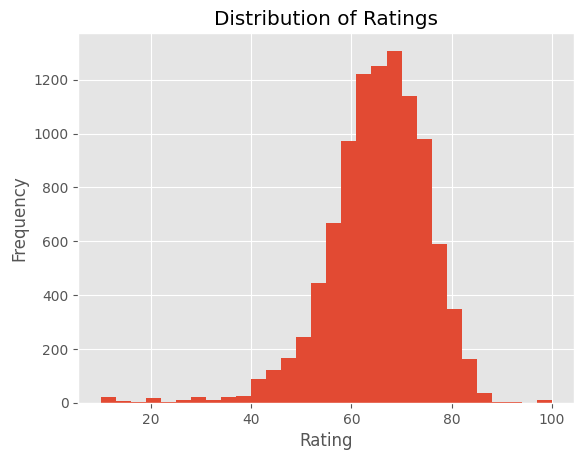

In [8]:
plt.figure()
plt.hist(df["score"], bins=30)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

## 6. Time evolution of scores

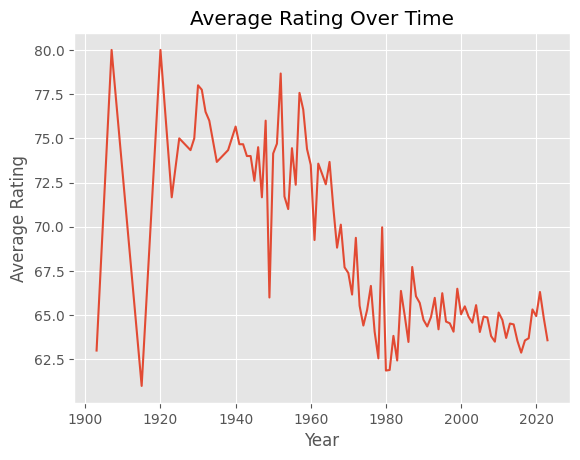

In [10]:
ratings_by_year = df.groupby("year")["score"].mean()

plt.figure()
ratings_by_year.plot()

plt.title("Average Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

# 7. Movie production over time

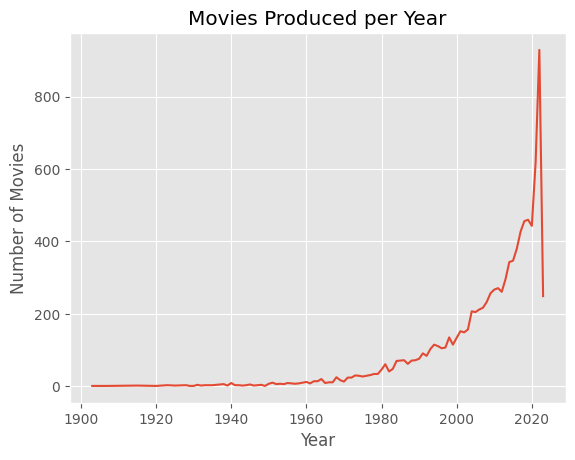

In [13]:
movies_per_year = df["year"].value_counts().sort_index()

plt.figure()
movies_per_year.plot()

plt.title("Movies Produced per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

# 8. Genre Analysis

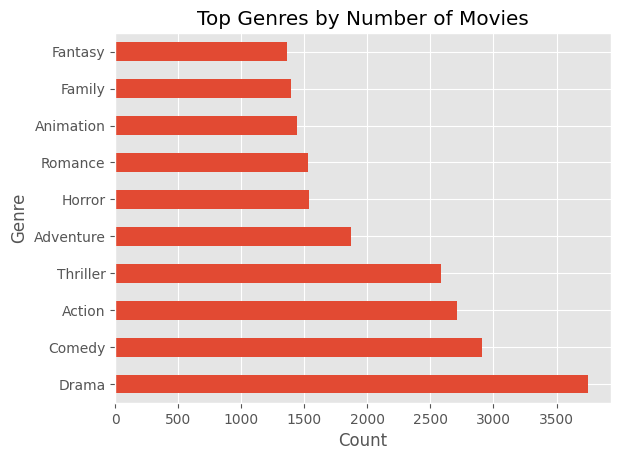

In [20]:
# Split multi-genre entries to enable per-genre analysis
df["genre"] = df["genre"].str.split(",")
df = df.explode("genre")
df["genre"] = df["genre"].str.strip()
# Identify dominant genres in terms of volume
genre_count = df["genre"].value_counts().head(10)

plt.figure()
genre_count.plot(kind="barh")

plt.title("Top Genres by Number of Movies")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

## 8.1 Highest rated genres

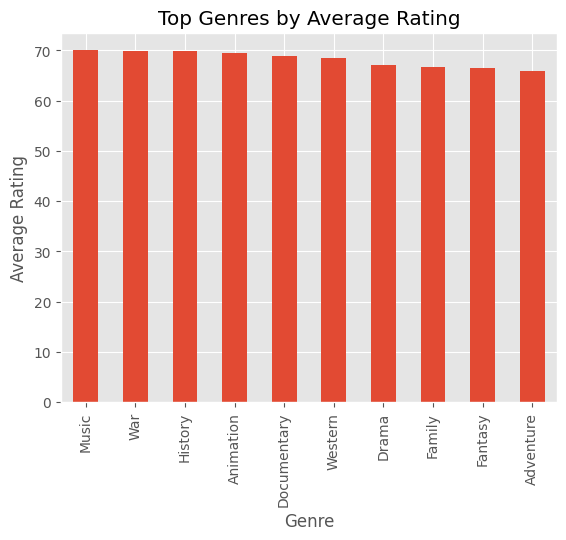

In [22]:
# Evaluate which genres receive the highest average ratings
counts = df["genre"].value_counts()
valid_genres = counts[counts > 50].index

genre_rating = df[df["genre"].isin(valid_genres)] \
    .groupby("genre")["score"].mean() \
    .sort_values(ascending=False)

plt.figure()
genre_rating.head(10).plot(kind="bar")

plt.title("Top Genres by Average Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.show()

# 9. Budget vs Rating

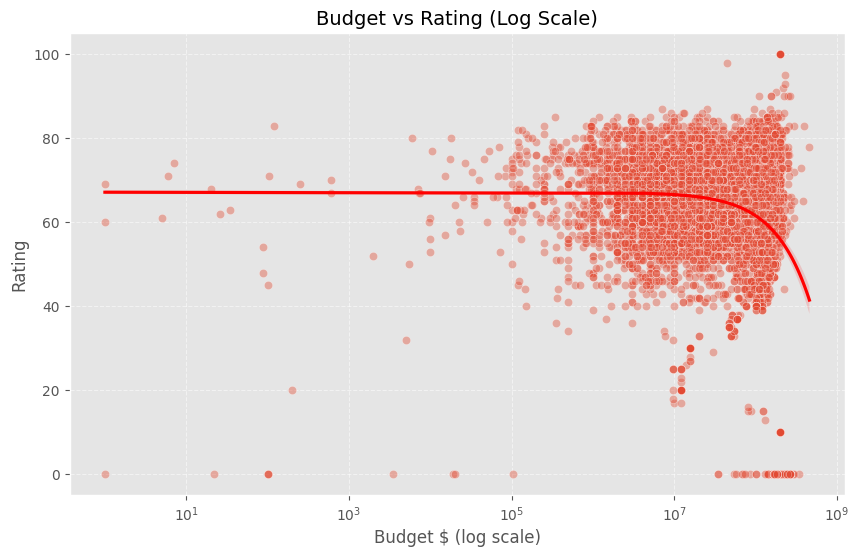

In [5]:
df_clean = df[(df["budget_x"] > 0) & (df["score"].notna())]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="budget_x",
    y="score",
    alpha=0.4  
)

plt.xscale("log")

sns.regplot(
    data=df_clean,
    x="budget_x",
    y="score",
    scatter=False,
    color="red"
)

plt.title("Budget vs Rating (Log Scale)", fontsize=14)
plt.xlabel("Budget $ (log scale)")
plt.ylabel("Rating")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# 10. Director analysis

In [ ]:
# Focus on directors with sufficient sample size to ensure reliability
if "director" in df.columns:
    
    counts = df["director"].value_counts()
    top_directors = counts[counts >= 5].index

    df_directors = df[df["director"].isin(top_directors)]